# H&E histological patch classification

Members: Théo, Jehan, Matthieu


## Imports and paths

Import the libraries that will be used:
- os for path management
- shutil to copy images into the quality control folder
- joblib to save and load the trained model
- sklearn for the machine learning algorithms
- numpy and pandas for math and data tables
- matplotlib for plotting and image reading

Feature extraction is implemented with NumPy operations only. The code does not
use skimage functions for thresholding, connected components, morphology,
region measurements, or texture descriptors.

We prepared the paths for the different folders and CSV files used later on.



In [15]:
import warnings
warnings.simplefilter("ignore")

import os
import shutil
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.metrics import f1_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import cross_val_predict
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# get the current root path of the program
CWD = os.getcwd()
ROOT_DIR = CWD

DATA_DIR = os.path.join(ROOT_DIR, 'data')
TRAIN_CSV = os.path.join(DATA_DIR, 'train.csv')
TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'datasetjehan')
TEST_IMG_DIR = os.path.join(DATA_DIR, 'tdatasetJehan')
QUALITY_DIR = os.path.join(DATA_DIR, 'quality_control')
FEATURES_TRAIN_CSV = os.path.join(DATA_DIR, 'features_train.csv')
MODEL_PATH = os.path.join(DATA_DIR, 'best_model.joblib')
FIG_DIR = os.path.join(DATA_DIR, 'figures')

N_EXAMPLES_PER_CLASS = 5
RANDOM_STATE = 42

os.makedirs(FIG_DIR, exist_ok=True)
print(CWD)


def read_rgb_image(path):
    """Read an image and return a RGB uint8 NumPy array.

    Matplotlib is used only for file reading. The feature computations in
    Part II are implemented with NumPy only.
    """
    img = plt.imread(path)

    if img.ndim == 2:
        img = np.stack([img, img, img], axis=-1)

    if img.shape[-1] == 4:
        img = img[:, :, :3]

    if np.issubdtype(img.dtype, np.floating):
        if img.max() <= 1.0:
            img = img * 255.0

    return np.clip(img, 0, 255).astype(np.uint8)


/workspaces/cell_classification/src


## Part I/ Data exploration

We start by loading the CSV file and summarize the dataset. We added a quality control folder and finally we display the label distribution to have a better idea of the repartition of the dataset. Hence, it will help us to see if there is imbalance between the classes, and we prepare the folders we will use later.


Total samples: 400
Labels: ['Fibroblast', 'Lymphocyte', 'Plasma', 'Tumor']


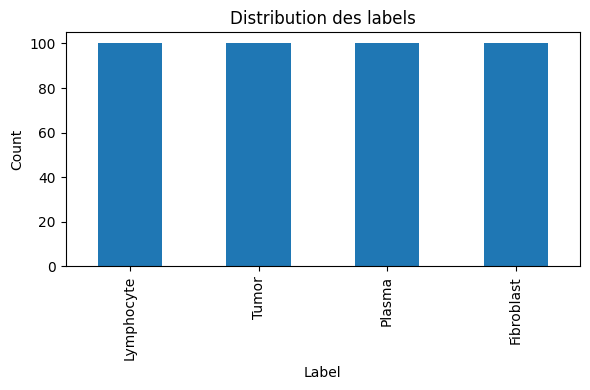

Imbalance ratio (max/min): 1.00


In [16]:
# loading of the CSV
train_df = pd.read_csv(TRAIN_CSV)

# global informations
num_samples = len(train_df)
label_names = sorted(train_df['Label'].unique())
label_counts = train_df['Label'].value_counts()

print(f'Total samples: {num_samples}')
print(f'Labels: {label_names}')

# label distribution plot
plt.figure(figsize=(6, 4))
label_counts.plot(kind='bar')
plt.title('Distribution des labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'label_distribution.png'))
plt.show()

# balance ratio
imbalance_ratio = label_counts.max() / label_counts.min()
print(f'Imbalance ratio (max/min): {imbalance_ratio:.2f}')

# quality control dir
os.makedirs(QUALITY_DIR, exist_ok=True)
for label in label_names:
    os.makedirs(os.path.join(QUALITY_DIR, str(label)),
                exist_ok=True)

def find_image_path(img_id, img_dir):
    #return the path for an existing file
    exts = ['.png', '.jpg', '.jpeg'] 
    for ext in exts:
        cand = os.path.join(img_dir, f'{img_id}{ext}')
        if os.path.exists(cand):
            return cand
    return None

# copy image per label
for _, row in train_df.iterrows():
    img_id = row['Image']
    label = row['Label']
    src_path = find_image_path(img_id, TRAIN_IMG_DIR)
    
    if src_path is None:
        continue
        
    dst_path = os.path.join(QUALITY_DIR, str(label), os.path.basename(src_path))
    
    if not os.path.exists(dst_path):
        shutil.copyfile(src_path, dst_path)


We can see first that there is 4 different labels: Fibroblast, lymphocyte, Plasma and Tumor. Those 4 labels has the exact same amount each, meaning that each class are perfectly balanced, moreover there is 400 total samples, which make this dataset really good for machine learning. It leaves enough images for both the training set and the testing set.
We chose not to remove pictures as there will be potentially similar one in the final dataset. 


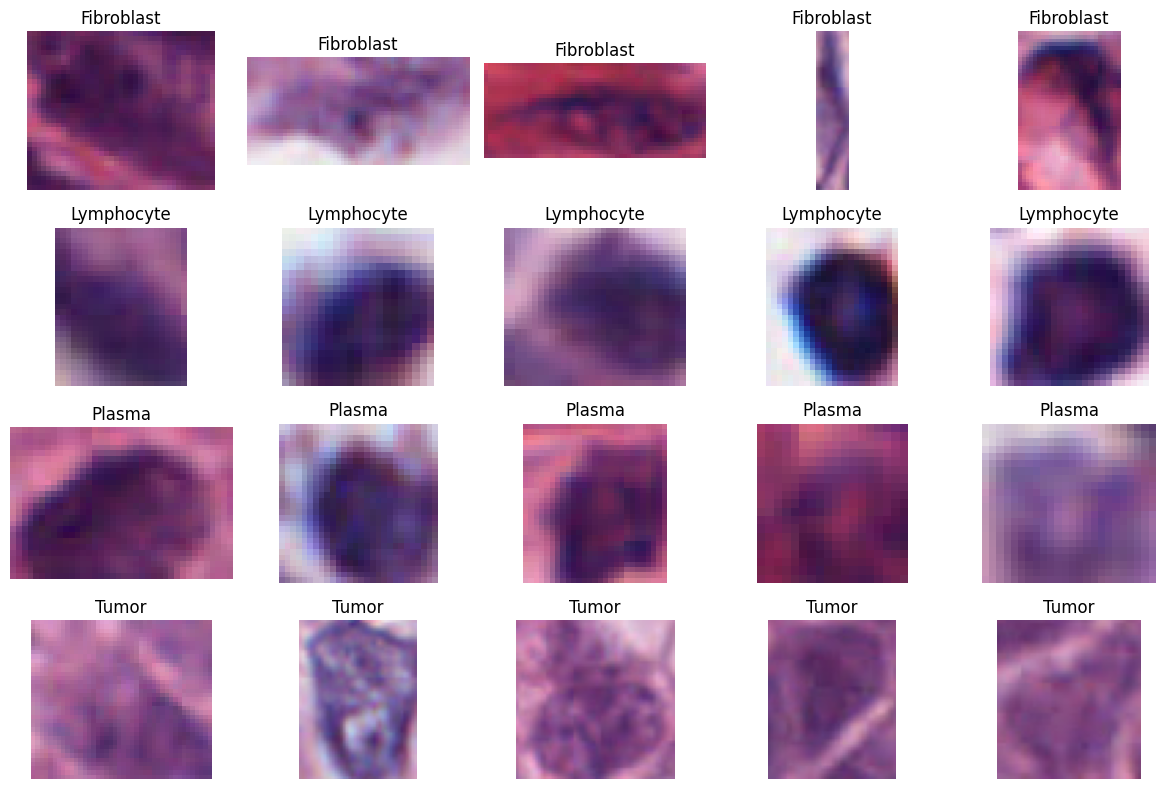

In [17]:
# exemple of each class

#prepare the random seed and the subplot space
np.random.seed(RANDOM_STATE)
fig, axes = plt.subplots(len(label_names),
                         N_EXAMPLES_PER_CLASS,
                         figsize=(12, 2 * len(label_names)))


#
for i, label in enumerate(label_names):
    subset = train_df[train_df['Label'] == label]
    sample_rows = subset.sample(
        n=min(N_EXAMPLES_PER_CLASS, len(subset)),
        random_state=RANDOM_STATE
    )
    
    for j, (_, row) in enumerate(sample_rows.iterrows()):
        img_path = find_image_path(row['Image'],
                                  TRAIN_IMG_DIR)
        ax = axes[i, j] if len(label_names) > 1 else axes[j]
        ax.axis('off')
        if img_path is None:
            ax.set_title('Missing')
            continue

        img = read_rgb_image(img_path)
        ax.imshow(img)
        ax.set_title(str(label))

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'examples_grid.png'))
plt.show()


From a first glance, we can see few differences between the classes and already imagines which ones will be harder or easier to classify. For instance, the Lymphocyte is long and has a really distinctive shape compared to the other types which are really round such as the lymphocytes and the plasma. We cal also see that lymphocytes are especially dark, but some look simirlar to some pictures of plasma. However their colors do are a bit different, lyphocyte are more blue, where the plasma seems to have some tints of red and blue, and more variation in color within the plasma. The Tumor's seems bigger than the others with a different texture in it. I can also see that the tumor seems to have a different texture than the others. Finally, 

Through this first analyse, I predict that firbroblast and tumors will be the easiest to predict, wherease Plasma and lymphocyte whom can be similar will be harder.


## Part II/ feature extraction

The project asks us to extract homemade features and suggests using very basic
libraries such as NumPy. For this reason, every feature below is computed with
NumPy only. I do not use `skimage.measure.label`, `skimage.morphology`,
`skimage.filters`, or `skimage.feature` for feature extraction.

The selected handmade features are:

- Area: proportion of pixels belonging to the detected tissue/cell region.
- Shape: elongation, compactness and bounding-box aspect ratio.
- Intensity: mean grayscale intensity and ratio of dark pixels.
- Color: mean and standard deviation of red and blue channels.
- Texture: homemade GLCM descriptors implemented with NumPy.
- Perimeter: normalized contour length of the main detected region.


In [18]:
# Image preprocessing using NumPy only for computations

def load_rgb_image(path):
    """Load an image as RGB uint8.

    The image reading itself uses the helper defined in the imports cell.
    All following transformations are NumPy operations.
    """
    return read_rgb_image(path)


def grayscale_image(rgb):
    """Convert RGB image to grayscale with a classical weighted formula."""
    rgb_float = rgb.astype(np.float32) / 255.0
    red = rgb_float[:, :, 0]
    green = rgb_float[:, :, 1]
    blue = rgb_float[:, :, 2]
    return 0.299 * red + 0.587 * green + 0.114 * blue


def otsu_threshold_np(gray):
    """Compute Otsu threshold using NumPy histogram operations."""
    gray_u8 = np.clip(gray * 255.0, 0, 255).astype(np.uint8)
    hist = np.bincount(gray_u8.ravel(), minlength=256).astype(np.float64)

    total = gray_u8.size
    levels = np.arange(256)
    weight_back = np.cumsum(hist)
    weight_fore = total - weight_back

    sum_back = np.cumsum(hist * levels)
    sum_total = sum_back[-1]

    valid = (weight_back > 0) & (weight_fore > 0)
    mean_back = np.zeros_like(sum_back)
    mean_fore = np.zeros_like(sum_back)
    mean_back[valid] = sum_back[valid] / weight_back[valid]
    mean_fore[valid] = (sum_total - sum_back[valid]) / weight_fore[valid]

    between_var = np.zeros_like(sum_back)
    between_var[valid] = (
        weight_back[valid]
        * weight_fore[valid]
        * (mean_back[valid] - mean_fore[valid]) ** 2
    )

    threshold = np.argmax(between_var) / 255.0
    return float(threshold)


def connected_components_np(mask):
    """Label connected components with 8-connectivity using NumPy arrays."""
    mask = mask.astype(bool)
    height, width = mask.shape
    labels = np.zeros((height, width), dtype=np.int32)
    current_label = 0
    sizes = []

    for row in range(height):
        for col in range(width):
            if not mask[row, col] or labels[row, col] != 0:
                continue

            current_label += 1
            stack = [(row, col)]
            labels[row, col] = current_label
            size = 0

            while stack:
                r, c = stack.pop()
                size += 1

                for dr in (-1, 0, 1):
                    for dc in (-1, 0, 1):
                        if dr == 0 and dc == 0:
                            continue

                        rr = r + dr
                        cc = c + dc

                        if rr < 0 or rr >= height or cc < 0 or cc >= width:
                            continue

                        if mask[rr, cc] and labels[rr, cc] == 0:
                            labels[rr, cc] = current_label
                            stack.append((rr, cc))

            sizes.append(size)

    return labels, np.array(sizes, dtype=np.int32)


def remove_small_components_np(mask, min_size=16):
    """Remove connected foreground components smaller than min_size."""
    labels, sizes = connected_components_np(mask)
    cleaned = np.zeros_like(mask, dtype=bool)

    for label_id, size in enumerate(sizes, start=1):
        if size >= min_size:
            cleaned |= labels == label_id

    return cleaned


def fill_small_holes_np(mask, max_size=16):
    """Fill small background components not connected to the image border."""
    background = ~mask.astype(bool)
    labels, sizes = connected_components_np(background)
    filled = mask.copy().astype(bool)

    if len(sizes) == 0:
        return filled

    border_labels = set(labels[0, :])
    border_labels.update(labels[-1, :])
    border_labels.update(labels[:, 0])
    border_labels.update(labels[:, -1])
    border_labels.discard(0)

    for label_id, size in enumerate(sizes, start=1):
        if label_id not in border_labels and size <= max_size:
            filled[labels == label_id] = True

    return filled


def tissue_mask(rgb):
    """Detect dark tissue/cell pixels with NumPy Otsu thresholding."""
    gray = grayscale_image(rgb)
    threshold = otsu_threshold_np(gray)
    mask = gray < threshold

    ratio = mask.mean()
    if ratio < 0.01 or ratio > 0.95:
        mask = gray < np.percentile(gray, 90)

    mask = remove_small_components_np(mask, min_size=16)
    mask = fill_small_holes_np(mask, max_size=16)
    return mask


def largest_component_np(mask):
    """Return only the largest connected foreground component."""
    labels, sizes = connected_components_np(mask)

    if len(sizes) == 0:
        return None

    largest_label = int(np.argmax(sizes) + 1)
    return labels == largest_label


def perimeter_np(mask):
    """Approximate perimeter by counting foreground pixels touching background."""
    mask = mask.astype(bool)
    padded = np.pad(mask, 1, mode='constant', constant_values=False)
    center = padded[1:-1, 1:-1]
    up = padded[:-2, 1:-1]
    down = padded[2:, 1:-1]
    left = padded[1:-1, :-2]
    right = padded[1:-1, 2:]

    border = center & (~up | ~down | ~left | ~right)
    return float(np.sum(border))


def region_measurements_np(mask):
    """Compute basic measurements for the largest connected region."""
    component = largest_component_np(mask)

    if component is None or not np.any(component):
        return None

    rows, cols = np.nonzero(component)
    area = float(len(rows))
    min_row = int(rows.min())
    max_row = int(rows.max())
    min_col = int(cols.min())
    max_col = int(cols.max())
    height = max(max_row - min_row + 1, 1)
    width = max(max_col - min_col + 1, 1)
    perimeter = max(perimeter_np(component), 1e-6)

    coords = np.column_stack((rows, cols)).astype(np.float64)

    if coords.shape[0] < 2:
        eccentricity = 0.0
    else:
        cov = np.cov(coords, rowvar=False)
        eigvals = np.linalg.eigvalsh(cov)
        eigvals = np.sort(np.maximum(eigvals, 0.0))

        if eigvals[-1] <= 1e-12:
            eccentricity = 0.0
        else:
            eccentricity = np.sqrt(1.0 - eigvals[0] / eigvals[-1])

    compactness = 4.0 * np.pi * area / (perimeter ** 2)

    return {
        'component': component,
        'area': area,
        'height': height,
        'width': width,
        'perimeter': perimeter,
        'eccentricity': float(eccentricity),
        'compactness': float(compactness),
    }


### Area, shape and perimeter features

These features are computed from the largest connected component of the mask.
The connected-component labeling, perimeter, compactness and eccentricity are
implemented manually with NumPy. This replaces `skimage.measure.label` and
`skimage.regionprops`.


In [19]:
def area_shape_perimeter_features(mask):
    """Compute area, shape and perimeter features with NumPy."""
    area_ratio = float(mask.mean())
    measurements = region_measurements_np(mask)

    if measurements is None:
        return {
            'area_ratio': area_ratio,
            'bbox_aspect_ratio': 0.0,
            'eccentricity': 0.0,
            'compactness': 0.0,
            'perimeter_ratio': 0.0,
        }

    height = measurements['height']
    width = measurements['width']
    perimeter = measurements['perimeter']

    return {
        'area_ratio': area_ratio,
        'bbox_aspect_ratio': float(height / width),
        'eccentricity': measurements['eccentricity'],
        'compactness': measurements['compactness'],
        'perimeter_ratio': float(perimeter / mask.size),
    }


### Intensity and color features

The visual inspection suggested that lymphocytes and plasma cells are darker
and more blue/purple than some other patches. The following color features use
only NumPy operations on the masked pixels.


In [20]:
def _masked_values(channel, mask):
    """Return channel values inside the mask, or all values if mask is empty."""
    if np.any(mask):
        return channel[mask].reshape(-1)

    return channel.reshape(-1)


def intensity_color_features(rgb, mask):
    """Compute intensity and color statistics with NumPy."""
    rgb_float = rgb.astype(np.float32) / 255.0
    gray = grayscale_image(rgb)

    gray_values = _masked_values(gray, mask)
    red_values = _masked_values(rgb_float[:, :, 0], mask)
    blue_values = _masked_values(rgb_float[:, :, 2], mask)

    dark_pixel_ratio = float(np.mean(gray_values < 0.35))

    return {
        'gray_mean': float(np.mean(gray_values)),
        'gray_std': float(np.std(gray_values)),
        'dark_pixel_ratio': dark_pixel_ratio,
        'red_mean': float(np.mean(red_values)),
        'blue_mean': float(np.mean(blue_values)),
        'red_std': float(np.std(red_values)),
        'blue_std': float(np.std(blue_values)),
        'blue_red_ratio': float(np.mean(blue_values) / (np.mean(red_values) + 1e-6)),
    }


### Texture features

The GLCM-like descriptors are also implemented manually with NumPy. They are
not computed with `skimage.feature.graycomatrix` or `graycoprops`.

The retained texture descriptors are contrast, homogeneity, energy,
correlation, entropy and dynamic range.


In [21]:
def quantize_gray_np(gray, levels=32):
    """Quantize grayscale image into a fixed number of gray levels."""
    gray_u8 = np.clip(gray * 255.0, 0, 255).astype(np.uint8)
    factor = 256 // levels
    return (gray_u8 // factor).astype(np.uint8)


def glcm_np(gray_q, levels=32):
    """Build normalized GLCMs for four directions using NumPy."""
    directions = [
        (0, 1),     # 0 degrees
        (-1, 1),    # 45 degrees
        (-1, 0),    # 90 degrees
        (-1, -1),   # 135 degrees
    ]

    matrices = []
    height, width = gray_q.shape

    for dr, dc in directions:
        row_start_a = max(0, -dr)
        row_end_a = min(height, height - dr)
        col_start_a = max(0, -dc)
        col_end_a = min(width, width - dc)

        row_start_b = row_start_a + dr
        row_end_b = row_end_a + dr
        col_start_b = col_start_a + dc
        col_end_b = col_end_a + dc

        a = gray_q[row_start_a:row_end_a, col_start_a:col_end_a].ravel()
        b = gray_q[row_start_b:row_end_b, col_start_b:col_end_b].ravel()

        matrix = np.zeros((levels, levels), dtype=np.float64)
        np.add.at(matrix, (a, b), 1)

        # Symmetric GLCM, equivalent to counting both directions.
        matrix = matrix + matrix.T

        total = matrix.sum()
        if total > 0:
            matrix = matrix / total

        matrices.append(matrix)

    return np.stack(matrices, axis=0)


def glcm_properties_np(glcms):
    """Extract classical GLCM descriptors with NumPy formulas."""
    levels = glcms.shape[1]
    i, j = np.meshgrid(np.arange(levels), np.arange(levels), indexing='ij')

    contrasts = []
    homogeneities = []
    energies = []
    correlations = []
    entropies = []

    for matrix in glcms:
        contrast = np.sum(((i - j) ** 2) * matrix)
        homogeneity = np.sum(matrix / (1.0 + np.abs(i - j)))
        energy = np.sqrt(np.sum(matrix ** 2))

        px = matrix.sum(axis=1)
        py = matrix.sum(axis=0)
        mean_x = np.sum(np.arange(levels) * px)
        mean_y = np.sum(np.arange(levels) * py)
        std_x = np.sqrt(np.sum(((np.arange(levels) - mean_x) ** 2) * px))
        std_y = np.sqrt(np.sum(((np.arange(levels) - mean_y) ** 2) * py))

        if std_x < 1e-12 or std_y < 1e-12:
            correlation = 0.0
        else:
            correlation = np.sum(
                (i - mean_x) * (j - mean_y) * matrix
            ) / (std_x * std_y)

        positive = matrix[matrix > 0]
        entropy = -np.sum(positive * np.log2(positive))

        contrasts.append(contrast)
        homogeneities.append(homogeneity)
        energies.append(energy)
        correlations.append(correlation)
        entropies.append(entropy)

    return {
        'texture_contrast': float(np.mean(contrasts)),
        'texture_homogeneity': float(np.mean(homogeneities)),
        'texture_energy': float(np.mean(energies)),
        'texture_correlation': float(np.mean(correlations)),
        'texture_entropy': float(np.mean(entropies)),
    }


def local_variance_3x3_np(gray):
    """Compute a simple local variance map using 3x3 neighborhoods."""
    padded = np.pad(gray, 1, mode='edge')
    patches = []

    for dr in range(3):
        for dc in range(3):
            patches.append(padded[dr:dr + gray.shape[0], dc:dc + gray.shape[1]])

    stack = np.stack(patches, axis=0)
    return np.var(stack, axis=0)


def texture_features(rgb):
    """Compute texture descriptors with NumPy only."""
    gray = grayscale_image(rgb)
    gray_q = quantize_gray_np(gray, levels=32)
    glcms = glcm_np(gray_q, levels=32)
    features = glcm_properties_np(glcms)

    local_var = local_variance_3x3_np(gray)
    features.update({
        'texture_dynamic': float(np.max(gray_q) - np.min(gray_q)),
        'texture_local_var_mean': float(np.mean(local_var)),
        'texture_local_var_std': float(np.std(local_var)),
    })

    return features


def extract_features_from_path(img_path):
    """Extract all handmade NumPy features from one image."""
    rgb = load_rgb_image(img_path)
    mask = tissue_mask(rgb)

    features_dict = {}
    features_dict.update(area_shape_perimeter_features(mask))
    features_dict.update(intensity_color_features(rgb, mask))
    features_dict.update(texture_features(rgb))

    return features_dict


def build_feature_table(df, image_dir, include_labels=True):
    """Extract features for all images listed in a dataframe."""
    rows = []
    n_total = len(df)

    for count, (_, row) in enumerate(df.iterrows(), start=1):
        img_id = row['Image']
        img_path = find_image_path(img_id, image_dir)

        if img_path is None:
            print(f'Missing image: {img_id}')
            continue

        try:
            features_row = extract_features_from_path(img_path)
        except Exception as exc:
            print(f'Error with {img_id}: {exc}')
            continue

        features_row['Image'] = img_id

        if include_labels:
            features_row['Label'] = row['Label']

        rows.append(features_row)

        if count % 50 == 0 or count == n_total:
            print(f'Processed {count}/{n_total} images')

    return pd.DataFrame(rows)


features_df = build_feature_table(
    train_df,
    TRAIN_IMG_DIR,
    include_labels=True,
)

features_df.to_csv(FEATURES_TRAIN_CSV, index=False)
print(f'Saved features to: {FEATURES_TRAIN_CSV}')
features_df.head()


Missing image: 0
Missing image: 1
Missing image: 2
Missing image: 3
Missing image: 4
Missing image: 5
Missing image: 6
Missing image: 7
Missing image: 8
Missing image: 9
Processed 50/400 images
Processed 100/400 images
Processed 150/400 images
Processed 200/400 images
Processed 250/400 images
Processed 300/400 images
Processed 350/400 images
Processed 400/400 images
Saved features to: /workspaces/cell_classification/src/data/features_train.csv


,area_ratio,bbox_aspect_ratio,eccentricity,compactness,perimeter_ratio,gray_mean,gray_std,dark_pixel_ratio,red_mean,blue_mean,...,texture_contrast,texture_homogeneity,texture_energy,texture_correlation,texture_entropy,texture_dynamic,texture_local_var_mean,texture_local_var_std,Image,Label
0,0.581224,0.968750,0.658423,0.912892,0.080816,0.485942,0.070441,0.028090,0.547648,0.629985,...,1.702200,0.638062,0.135371,0.951896,6.206298,18.0,0.001198,0.001447,10,Fibroblast
1,0.558442,0.750000,0.805596,1.093649,0.083333,0.141705,0.037224,1.000000,0.216887,0.249696,...,1.833780,0.677433,0.205402,0.937472,5.529364,19.0,0.001270,0.002237,11,Lymphocyte
2,0.660256,1.272727,0.622712,1.036962,0.101282,0.198216,0.077758,0.933981,0.226796,0.356109,...,4.855471,0.575716,0.166779,0.962796,6.491755,26.0,0.003606,0.005035,12,Lymphocyte
3,0.536585,1.000000,0.587653,0.272368,0.121356,0.418300,0.042483,0.066519,0.504743,0.572419,...,0.901265,0.710076,0.189285,0.939125,5.279718,16.0,0.000545,0.000577,13,Tumor
4,0.632937,0.462963,0.870014,0.367083,0.119709,0.626728,0.057392,0.000000,0.701654,0.726908,...,1.234571,0.655262,0.161987,0.936989,5.728568,17.0,0.000812,0.000810,14,Fibroblast


**Feature justification summary:**

- `area_ratio`: size of the detected tissue/cell region.
- `bbox_aspect_ratio`, `eccentricity`, `compactness`: shape descriptors.
- `perimeter_ratio`: normalized perimeter of the main detected region.
- `gray_mean`, `gray_std`, `dark_pixel_ratio`: intensity descriptors.
- `red_mean`, `blue_mean`, `red_std`, `blue_std`, `blue_red_ratio`: H&E
  color descriptors.
- `texture_contrast`, `texture_homogeneity`, `texture_energy`,
  `texture_correlation`, `texture_entropy`, `texture_dynamic`,
  `texture_local_var_mean`, `texture_local_var_std`: homemade texture
  descriptors implemented manually with NumPy.

The feature table is saved to CSV so that training can be restarted without
extracting all features again.

### Feature visualization

Boxplots help identify discriminative features. The correlation matrix helps
spot redundant features. Highly correlated features are not necessarily bad,
but removing some of them can simplify the model and reduce overfitting.


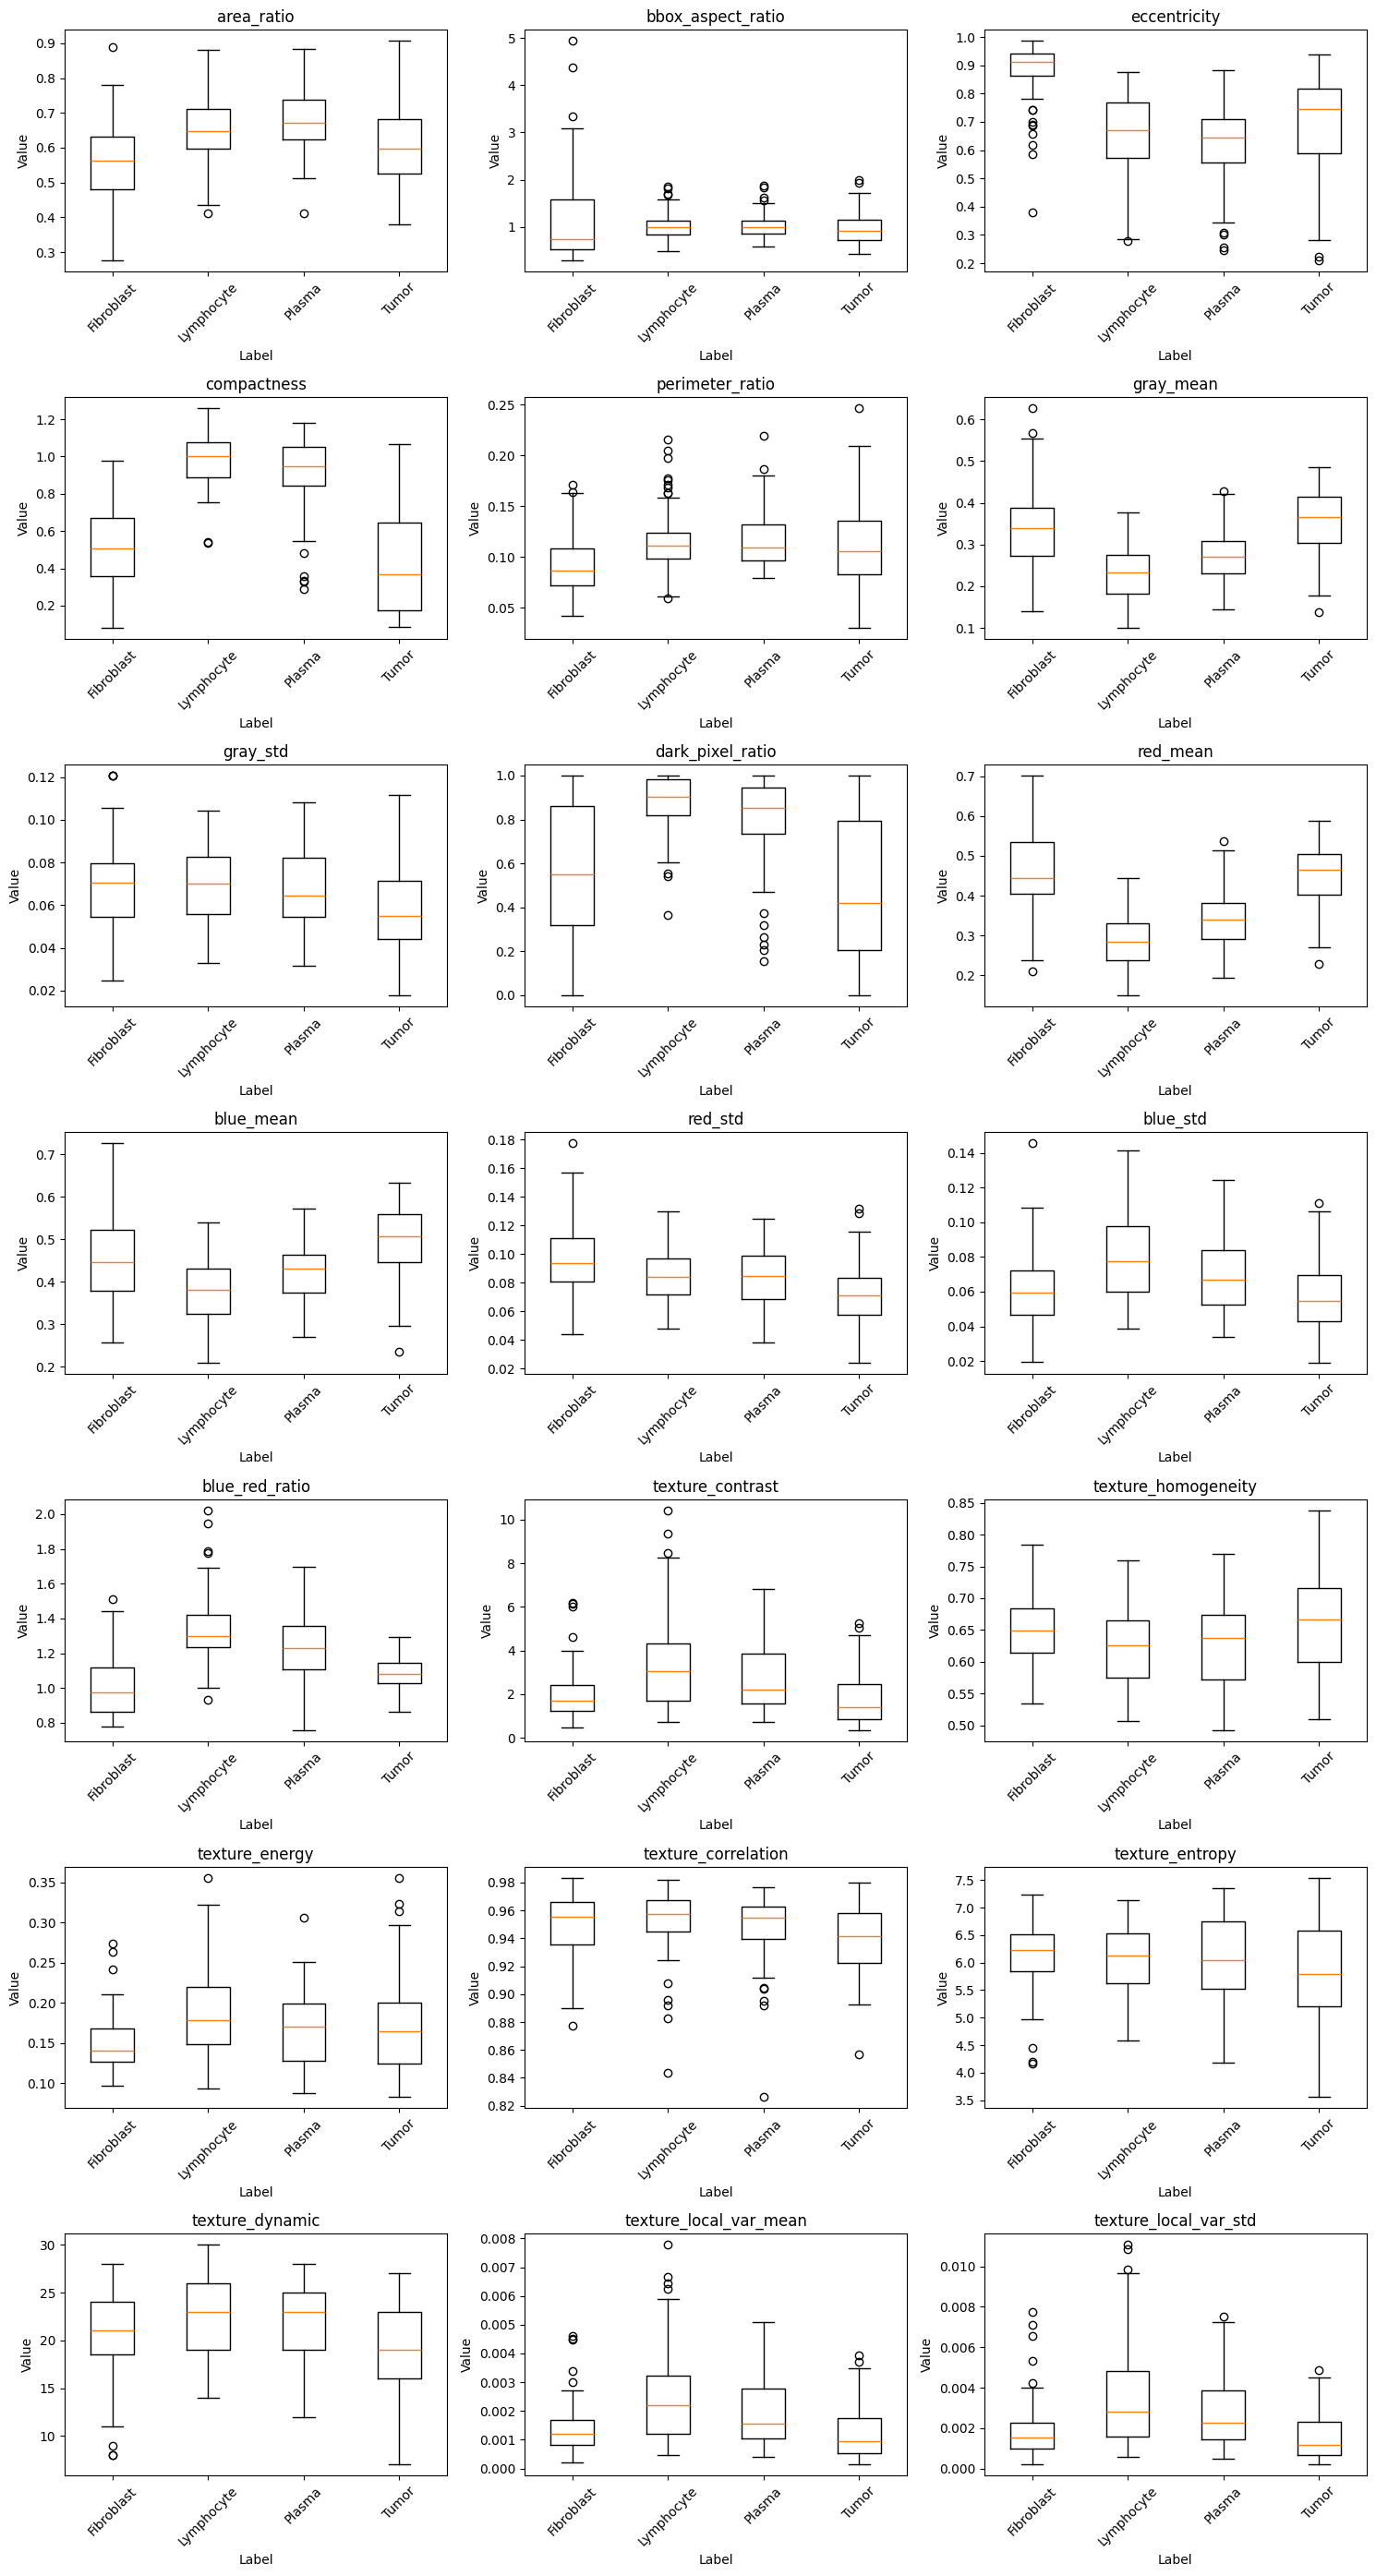

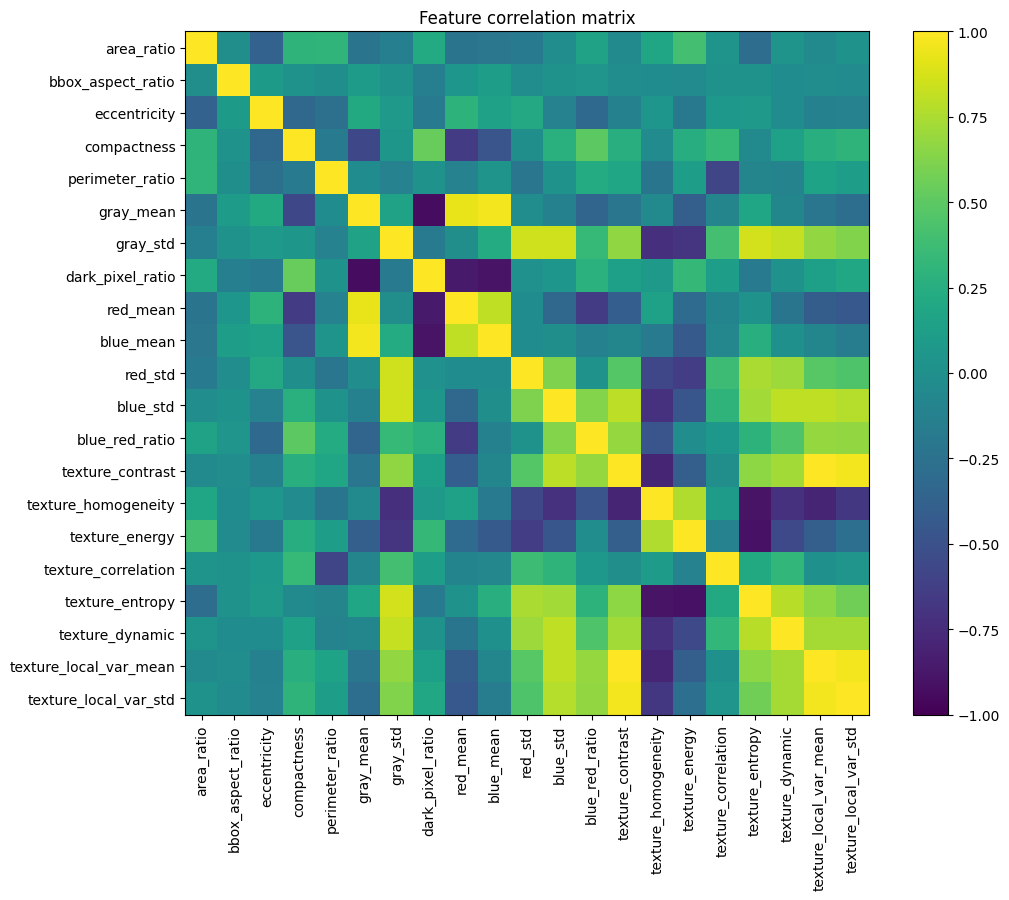

Highly correlated pairs (|r| > 0.90):
gray_mean / dark_pixel_ratio: -0.934
gray_mean / red_mean: 0.930
gray_mean / blue_mean: 0.963
texture_contrast / texture_local_var_mean: 0.999
texture_contrast / texture_local_var_std: 0.966
texture_energy / texture_entropy: -0.901
texture_local_var_mean / texture_local_var_std: 0.968


In [22]:
feature_cols = [
    col for col in features_df.columns
    if col not in ['Image', 'Label']
]

# Number of columns in the subplot grid
n_cols = 3
n_rows = int(np.ceil(len(feature_cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows)
)

axes = axes.ravel()

for i, feat_name in enumerate(feature_cols):
    data = [
        features_df[features_df['Label'] == lab][feat_name].dropna().values
        for lab in label_names
    ]

    axes[i].boxplot(data, labels=[str(lab) for lab in label_names])
    axes[i].set_title(feat_name)
    axes[i].set_xlabel('Label')
    axes[i].set_ylabel('Value')
    axes[i].tick_params(axis='x', rotation=45)

# Hide unused subplot spaces
for j in range(len(feature_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'features_boxplots_grid.png'))
plt.show()


corr = features_df[feature_cols].corr()
plt.figure(figsize=(11, 9))
plt.imshow(corr, vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(feature_cols)), feature_cols, rotation=90)
plt.yticks(range(len(feature_cols)), feature_cols)
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'features_corr.png'))
plt.show()


high_corr_pairs = []

for i, feat_a in enumerate(feature_cols):
    for feat_b in feature_cols[i + 1:]:
        value = corr.loc[feat_a, feat_b]
        if abs(value) > 0.90:
            high_corr_pairs.append((feat_a, feat_b, value))

print('Highly correlated pairs (|r| > 0.90):')
for feat_a, feat_b, value in high_corr_pairs:
    print(f'{feat_a} / {feat_b}: {value:.3f}')


**Analysis to complete after running:**

- Which boxplots show the clearest separation between labels?
- Which features are almost redundant according to the correlation matrix?
- Are the visual observations from Part I consistent with the numerical
  features?

## Part III — Machine learning training

This part uses `scikit-learn`. The pipeline includes:

1. removal of constant features,
2. imputation of missing values,
3. feature normalization,
4. univariate feature selection,
5. hyperparameter tuning by grid search,
6. stratified cross-validation.

The project asks for at least two classification algorithms studied during the
course. Here we compare:

- **Logistic Regression** with the `lbfgs` solver,
- **SGDClassifier**, optimized with stochastic gradient descent,
- **K-Nearest Neighbors**, a classical supervised classification baseline.


In [23]:
ml_df = pd.read_csv(FEATURES_TRAIN_CSV).dropna(subset=['Label'])

# Selected features only, based on visual analysis and boxplots
selected_feature_cols = [
    'eccentricity',
    'compactness',
    'dark_pixel_ratio',
    'gray_mean',
    'red_mean',
    'blue_mean',
    'texture_contrast',
    'texture_homogeneity',
    'texture_entropy',
    'area_ratio',
    'perimeter_ratio',
]

# Security check: verify that all selected features exist
missing_features = [
    col for col in selected_feature_cols
    if col not in ml_df.columns
]

if len(missing_features) > 0:
    raise ValueError(f'Missing selected features: {missing_features}')

feature_cols = selected_feature_cols

X = ml_df[feature_cols].values
y = ml_df['Label'].values

n_features = X.shape[1]

# Feature selection values tested during GridSearchCV
candidate_k_values = [5, 8, 10]
k_values = [
    k for k in candidate_k_values
    if k <= n_features
]
k_values.append('all')

# Stratified cross-validation keeps the same label distribution in each fold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

base_steps = [
    ('imputer', SimpleImputer(strategy='median')),

    # Removes constant features if any
    ('variance', VarianceThreshold()),

    # Feature normalization: important for SVM, Logistic Regression,
    # SGD and KNN-like distance-based methods
    ('scaler', StandardScaler()),

    # Feature selection: the best k features are selected inside
    # the cross-validation process to avoid data leakage
    ('select', SelectKBest(score_func=f_classif)),
]

models_and_grids = {
    'LogisticRegression_LBFGS': (
        LogisticRegression(
            class_weight='balanced',
            max_iter=5000,
            random_state=RANDOM_STATE,
            solver='lbfgs',
        ),
        {
            'select__k': k_values,
            'clf__C': [0.01, 0.1, 1.0, 10.0],
        },
    ),

    'SGD_Logistic': (
        SGDClassifier(
            class_weight='balanced',
            loss='log_loss',
            max_iter=5000,
            random_state=RANDOM_STATE,
            tol=1e-4,
        ),
        {
            'select__k': k_values,
            'clf__alpha': [1e-4, 1e-3, 1e-2],
            'clf__penalty': ['l2', 'l1', 'elasticnet'],
        },
    ),

    'SVM_RBF': (
        SVC(
            class_weight='balanced',
            kernel='rbf',
            random_state=RANDOM_STATE,
        ),
        {
            'select__k': k_values,
            'clf__C': [0.1, 1.0, 10.0, 100.0],
            'clf__gamma': ['scale', 0.01, 0.1, 1.0],
        },
    ),

    'RandomForest': (
        RandomForestClassifier(
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        {
            'select__k': k_values,
            'clf__n_estimators': [100, 200, 400],
            'clf__max_depth': [None, 3, 5, 10],
            'clf__min_samples_split': [2, 5, 10],
            'clf__min_samples_leaf': [1, 2, 4],
        },
    ),

    'DeepDecisionTree': (
        DecisionTreeClassifier(
            class_weight='balanced',
            random_state=RANDOM_STATE,
        ),
        {
            'select__k': k_values,
            'clf__criterion': ['gini', 'entropy'],
            'clf__max_depth': [None, 5, 10, 20],
            'clf__min_samples_split': [2, 5, 10],
            'clf__min_samples_leaf': [1, 2, 4],
        },
    ),
}

algorithm_notes = {
    'LogisticRegression_LBFGS':
        'Linear model optimized with L-BFGS. Fast and interpretable, '
        'but limited if class boundaries are non-linear.',

    'SGD_Logistic':
        'Linear logistic model optimized with stochastic gradient descent. '
        'Useful to explicitly test a gradient-based optimization algorithm.',

    'SVM_RBF':
        'Non-linear model using an RBF kernel. Relevant when classes are '
        'not linearly separable, but sensitive to normalization and C/gamma.',

    'RandomForest':
        'Ensemble of decision trees. Robust to non-linear relations and '
        'useful for feature importance, but can overfit if trees are too deep.',

    'DeepDecisionTree':
        'Single deep decision tree. Easy to interpret, but very sensitive '
        'to overfitting, so max_depth and leaf size must be tuned.',
}

print('Selected features used for ML:')
for col in feature_cols:
    print('-', col)

print('\nNumber of selected features:', len(feature_cols))
print('Feature selection k values tested:', k_values)

Selected features used for ML:
- eccentricity
- compactness
- dark_pixel_ratio
- gray_mean
- red_mean
- blue_mean
- texture_contrast
- texture_homogeneity
- texture_entropy
- area_ratio
- perimeter_ratio

Number of selected features: 11
Feature selection k values tested: [5, 8, 10, 'all']


**Why weighted F1 is used for tuning:** accuracy can be misleading if classes
are imbalanced. Weighted F1 keeps all classes in the evaluation while giving a
summary score for model selection. Balanced accuracy is also reported below to
check if minority classes are ignored.


In [24]:
searches = {}
summary_rows = []

for model_name, (classifier, param_grid) in models_and_grids.items():
    print(f'\nTraining: {model_name}')
    print(algorithm_notes[model_name])

    pipeline = Pipeline(base_steps + [('clf', classifier)])

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring='f1_weighted',
        cv=cv,
        n_jobs=-1,
        refit=True,
    )

    search.fit(X, y)
    searches[model_name] = search

    preds = cross_val_predict(
        search.best_estimator_,
        X,
        y,
        cv=cv
    )

    summary_rows.append({
        'model': model_name,
        'best_cv_f1_weighted': search.best_score_,
        'accuracy': accuracy_score(y, preds),
        'balanced_accuracy': balanced_accuracy_score(y, preds),
        'f1_weighted': f1_score(y, preds, average='weighted'),
        'best_params': search.best_params_,
        'optimization_algorithm': algorithm_notes[model_name],
    })

results_df = pd.DataFrame(summary_rows)
results_df = results_df.sort_values(
    'f1_weighted',
    ascending=False
)

results_df


Training: LogisticRegression_LBFGS
Linear model optimized with L-BFGS. Fast and interpretable, but limited if class boundaries are non-linear.

Training: SGD_Logistic
Linear logistic model optimized with stochastic gradient descent. Useful to explicitly test a gradient-based optimization algorithm.

Training: SVM_RBF
Non-linear model using an RBF kernel. Relevant when classes are not linearly separable, but sensitive to normalization and C/gamma.

Training: RandomForest
Ensemble of decision trees. Robust to non-linear relations and useful for feature importance, but can overfit if trees are too deep.

Training: DeepDecisionTree
Single deep decision tree. Easy to interpret, but very sensitive to overfitting, so max_depth and leaf size must be tuned.


,model,best_cv_f1_weighted,accuracy,balanced_accuracy,f1_weighted,best_params,optimization_algorithm
2,SVM_RBF,0.738889,0.738462,0.737562,0.739551,"{'clf__C': 100.0, 'clf__gamma': 0.01, 'select_...",Non-linear model using an RBF kernel. Relevant...
0,LogisticRegression_LBFGS,0.737885,0.738462,0.737588,0.739391,"{'clf__C': 10.0, 'select__k': 10}",Linear model optimized with L-BFGS. Fast and i...
1,SGD_Logistic,0.713561,0.720513,0.719943,0.719462,"{'clf__alpha': 0.001, 'clf__penalty': 'elastic...",Linear logistic model optimized with stochasti...
3,RandomForest,0.716944,0.717949,0.716759,0.718153,"{'clf__max_depth': None, 'clf__min_samples_lea...",Ensemble of decision trees. Robust to non-line...
4,DeepDecisionTree,0.651393,0.651282,0.650005,0.652508,"{'clf__criterion': 'entropy', 'clf__max_depth'...","Single deep decision tree. Easy to interpret, ..."


Best model: SVM_RBF
Best parameters:
{'clf__C': 100.0, 'clf__gamma': 0.01, 'select__k': 8}


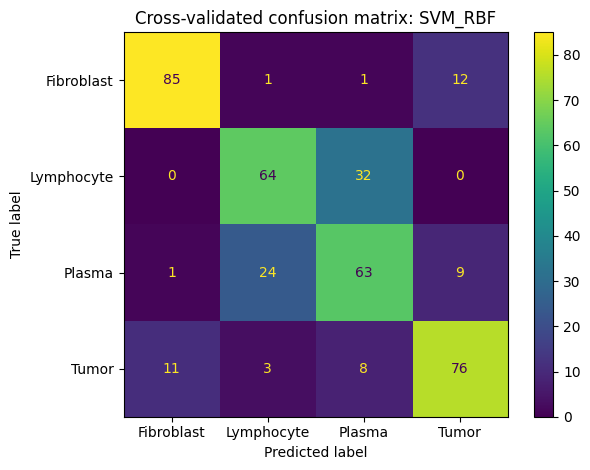

Saved model to: /workspaces/cell_classification/src/data/best_model.joblib


In [25]:
best_model_name = results_df.iloc[0]['model']
best_model = searches[best_model_name].best_estimator_

print(f'Best model: {best_model_name}')
print('Best parameters:')
print(searches[best_model_name].best_params_)

best_preds = cross_val_predict(
    best_model,
    X,
    y,
    cv=cv
)

cm = confusion_matrix(
    y,
    best_preds,
    labels=label_names
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_names,
)

display.plot()
plt.title(f'Cross-validated confusion matrix: {best_model_name}')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'confusion_matrix.png'))
plt.show()

best_model.fit(X, y)

joblib.dump({
    'model': best_model,
    'feature_cols': feature_cols,
    'label_names': label_names,
}, MODEL_PATH)

print(f'Saved model to: {MODEL_PATH}')

**Model-choice interpretation to complete after running:**

- Compare `f1_weighted` and `balanced_accuracy` for the three algorithms.
- Use the confusion matrix to identify which labels are confused most often.
- Keep the model with the best cross-validated F1 score, unless it clearly
  fails on one class according to the confusion matrix.

The selected model is fitted again on all available training samples and saved
with `joblib` for the test phase.

## Part IV — Prediction on the future test set

This code is ready for the test phase. When the test image folder becomes
available, it extracts the same features, applies the selected model, and saves
`test.csv` with the same column structure as `train.csv`: `Image`, `Label`.


In [ ]:
def make_test_dataframe(test_img_dir):
    """Create a dataframe containing test image identifiers."""
    image_files = [
        file_name for file_name in os.listdir(test_img_dir)
        if file_name.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]
    image_files = sorted(image_files)
    image_ids = [os.path.splitext(file_name)[0] for file_name in image_files]
    return pd.DataFrame({'Image': image_ids})


def predict_test_set(test_img_dir, output_csv):
    """Extract test features and save predicted labels."""
    if not os.path.exists(test_img_dir):
        print('Test directory not found. No prediction file was created.')
        return None

    saved = joblib.load(MODEL_PATH)
    trained_model = saved['model']
    saved_feature_cols = saved['feature_cols']

    test_df = make_test_dataframe(test_img_dir)
    test_features_df = build_feature_table(
        test_df,
        test_img_dir,
        include_labels=False,
    )

    for col in saved_feature_cols:
        if col not in test_features_df.columns:
            test_features_df[col] = 0.0

    X_test = test_features_df[saved_feature_cols].values
    predictions = trained_model.predict(X_test)

    output_df = pd.DataFrame({
        'Image': test_features_df['Image'].values,
        'Label': predictions,
    })
    output_df.to_csv(output_csv, index=False)
    print(f'Saved predictions to: {output_csv}')
    return output_df


TEST_OUTPUT_CSV = os.path.join(DATA_DIR, 'test.csv')

if os.path.exists(TEST_IMG_DIR):
    test_predictions = predict_test_set(TEST_IMG_DIR, TEST_OUTPUT_CSV)
else:
    print('Test image folder is not available yet.')


## Final checklist before submission

- Restart the kernel and run all cells.
- Check that no error message remains.
- Complete the short written analyses after the figures.
- Verify that `features_train.csv`, `best_model.joblib`, and `test.csv` are
  created when the corresponding folders exist.
- Keep the notebook filename simple, with no spaces or special characters.
